<a href="https://colab.research.google.com/github/aurabinda90-dev/CFD-in-Python/blob/main/Step_12_2D_Poisson_Equation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Step 12: 2D Poisson Equation

In [1]:
import numpy as np
from matplotlib import pyplot as plt, cm
from mpl_toolkits.mplot3d import Axes3D

In [2]:
# parameter definitions

nx = 50
ny = 50
nt = 100
xmin = 0
xmax = 2
ymin = 0
ymax = 2

dx = (xmax - xmin) / (nx - 1)
dy = (ymax - ymin) / (ny - 1)

p = np.zeros((nx, ny))
b = np.zeros((nx, ny))
x = np.linspace(xmin, xmax, nx)
y = np.linspace(ymin, ymax, ny)

# define source term
b[int(nx/4),int(nx/4)] = 100
b[int(3*ny/4),int(3*ny/4)] = -100

In [3]:
def plot2D(x,y,p):  # define a function for visulizing 2d plot
    fig = plt.figure(figsize = (11,7), dpi=100)
    ax = fig.add_subplot(111, projection='3d')
    # The '111' means a grid of 1 row and 1 column and this subplot is the first one.
    X, Y = np.meshgrid(x,y)
    surf = ax.plot_surface(X,Y,p,cmap=cm.viridis)
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$');

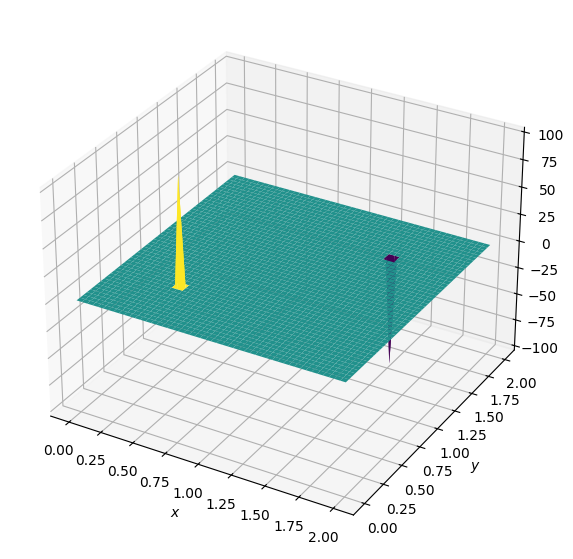

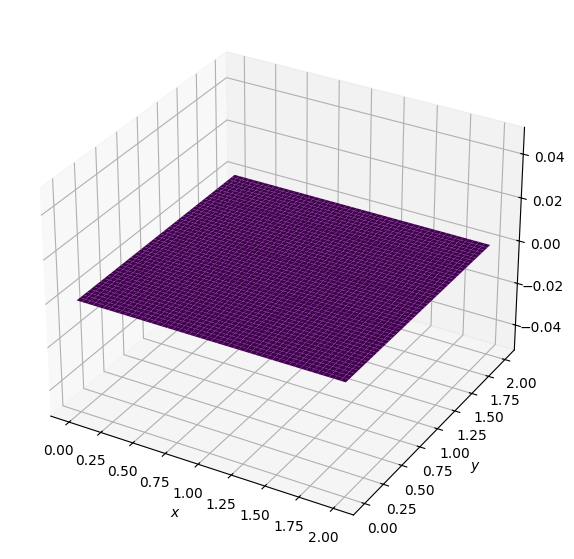

In [4]:
plot2D(x,y,b)
plot2D(x,y,p)

In [5]:
def poisson2d(p, b, dx, dy, l1norm_target):
    l1norm = 1
    pn = np.zeros_like(p)
    small = 1e-8
    niter = 0
    while l1norm > l1norm_target:
        niter += 1   # count the number of iterations for convergence
        pn = p.copy()
        p[1:-1,1:-1] = ((dy**2 * (pn[2:,1:-1] + pn[:-2,1:-1]) +
                        dx**2 * (pn[1:-1,2:] + pn[1:-1,:-2]) -
                        dx**2 * dy**2 * b[1:-1,1:-1]) /
                        (2 * (dx**2 + dy**2)))
        p[0,:] = 0  # p = 0 @ x = 0
        p[-1:,] = 0 # p = 0 @ x = 2
        p[:,0] = 0 # p = 0 @ y = 0
        p[:,-1] = 0 # p = 0 @ y = 2
        l1norm = (np.sum(np.abs(p[:]-pn[:])) / (np.sum(np.abs(pn[:]))+small))

    return p, niter

In [6]:
p, niter = poisson2d(p, b, dx, dy, 1e-4)
print('# of iterations =', niter)

# of iterations = 791


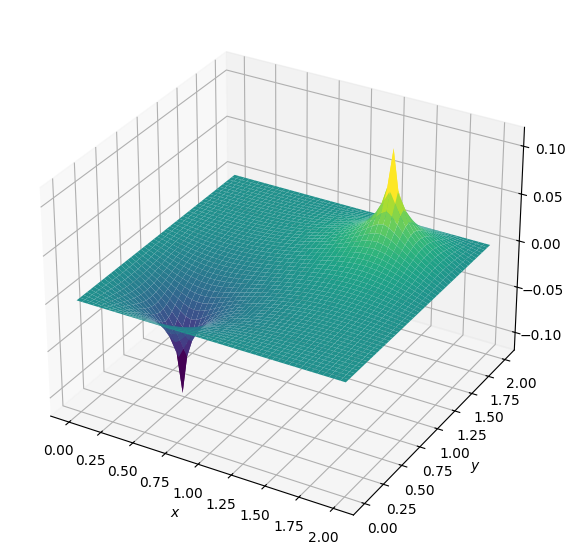

In [7]:
plot2D(x,y,p)